In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import os

from importlib import reload

import small_utilities
reload(small_utilities)
import Block_analysis
reload(Block_analysis)

from Block_analysis import *
from small_utilities import *

import seaborn as sns

In [2]:
def reposition_first(array):
    if len(array.shape) == 2:  # Check if it's 2D
        # Reposition first row to the last
        return np.vstack((array[1:], array[0]))
    elif len(array.shape) == 3:  # Check if it's 3D
        # Reposition first slice to the last
        return np.concatenate((array[1:], array[:1]), axis=0)

import matplotlib.pyplot as plt
import numpy as np

def plot_colvar(colvar, trj_frames, num_cvs, labels, weights=None, out_dir=None):
    """
    Plot collective variables over time with corresponding histograms and reweighted histograms.

    Parameters:
        colvar (np.ndarray): Array of collective variables with time as the first column.
        trj_frames (dict): Dictionary mapping frame indices to frame times.
        num_cvs (int): Number of collective variables.
        labels (dict): Dictionary of labels for the collective variables.
        weights (np.ndarray, optional): Normalized weights for reweighting histograms. Must match the number of frames.
        out_dir (str, optional): Directory to save the plot. If None, the plot is shown but not saved.
    """
    # Configure subplots
    height_ratios = [1] * (num_cvs - 1)
    fig, axes = plt.subplots(
        num_cvs - 1, 2, figsize=(32, 40),
        gridspec_kw={
            'width_ratios': [4, 1],
            'height_ratios': height_ratios,
            'left': 0.1, 'right': 0.9,
            'bottom': 0.1, 'top': 0.9,
            'wspace': 0.02, 'hspace': 0.2
        },
        sharey=False,
        # sharex=True
    )

    # Check if weights are provided
    if weights is not None:
        if len(weights) != colvar.shape[0]:
            raise ValueError("Weights must match the number of frames in colvar.")
        weights = weights / np.sum(weights)  # Normalize weights

    # Loop over collective variables
    for i in range(num_cvs - 1):
        time = colvar.T[0] / 10**5  # Time in appropriate units
        data = colvar.T[i + 1]  # Data for the i-th collective variable

        # Line plot of collective variable over time
        axes[i, 0].plot(time, data, color='r', label=labels.get(str(i + 1), f'CV {i + 1}'))
        axes[i, 0].set_ylabel(labels.get(str(i + 1), f'CV {i + 1}'), size=35)
        axes[i, 0].set_xlabel(r"Time ($\mu$s)", size=35)
        axes[i, 0].tick_params(labelsize=25)
        xticks=[frame_time[1] / 10**5 for frame_idx, frame_time in trj_frames.items()]

        axes[i, 0].set_xticks(xticks)

        # Add vertical lines for trajectory frames
        for frame_idx, frame_time in trj_frames.items():
            axes[i, 0].axvline(x=frame_time[1] / 10**5, color='black', linewidth=3, linestyle='--')

        # Plot histogram
        axes[i, 1].hist(data, bins=50, orientation='horizontal', density=True, color='black', histtype='step', linewidth=2)

        # Plot reweighted histogram (if weights are provided)
        if weights is not None:
            # # Compute weighted histogram
            # hist, bin_edges = np.histogram(data, bins=50, density=True, weights=weights)
            # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            # axes[i, 1].plot(hist, bin_centers, color='green', linewidth=2, label='Reweighted')
            axes[i, 1].hist(data, bins=50, orientation='horizontal', density=True, color='green', histtype='step', linewidth=2, weights=weights)


        axes[i, 1].tick_params(labelsize=25)
        axes[i, 1].set_yticks([])

    # Save or display the plot
    if out_dir:
        plt.savefig(f"{out_dir}/cv_plot.png", dpi=310, bbox_inches='tight')
    else:
        plt.show()

def create_trj_frames(colvar_data, nreps=16):
    """
    Create trajectory frame intervals based on the given data.

    Parameters:
        colvar_data (list): A list or array-like structure containing the data.
        nreps (int): Number of intervals (default is 16).
        index (int): Index of the dataset to process (default is 100).

    Returns:
        dict: A dictionary where keys are strings of interval indices and values are lists of start and end points.
    """
    # Determine the total length and calculate interval size
    total_frames = colvar_data.shape[0] - 1
    interval_size = total_frames / nreps

    # Initialize variables
    a, b = 0, interval_size
    trj_frames = {}

    # Create intervals
    for i in range(nreps):
        trj_frames[str(i)] = [a, b]
        a = b
        b += interval_size

    return trj_frames

In [3]:
rg=load_json('/Users/jayakrishnakoneru/Documents/work/plots_now/plot_data/fas/r2_10/rg.json')
sa=load_json('/Users/jayakrishnakoneru/Documents/work/plots_now/plot_data/fas/r2_10/sa.json')



In [35]:
X=rg['rep:0']
Y=np.sum(sa['rep:0'], axis=0)

data=np.stack([X,Y])

data.shape

(2, 24244)

In [96]:
data.shape

(2, 24244)

In [123]:
data.min(-1)

array([0.76944372, 0.04686732])

In [124]:
data.shape

(2, 24244)

In [170]:
size

47

In [173]:
index

9

47


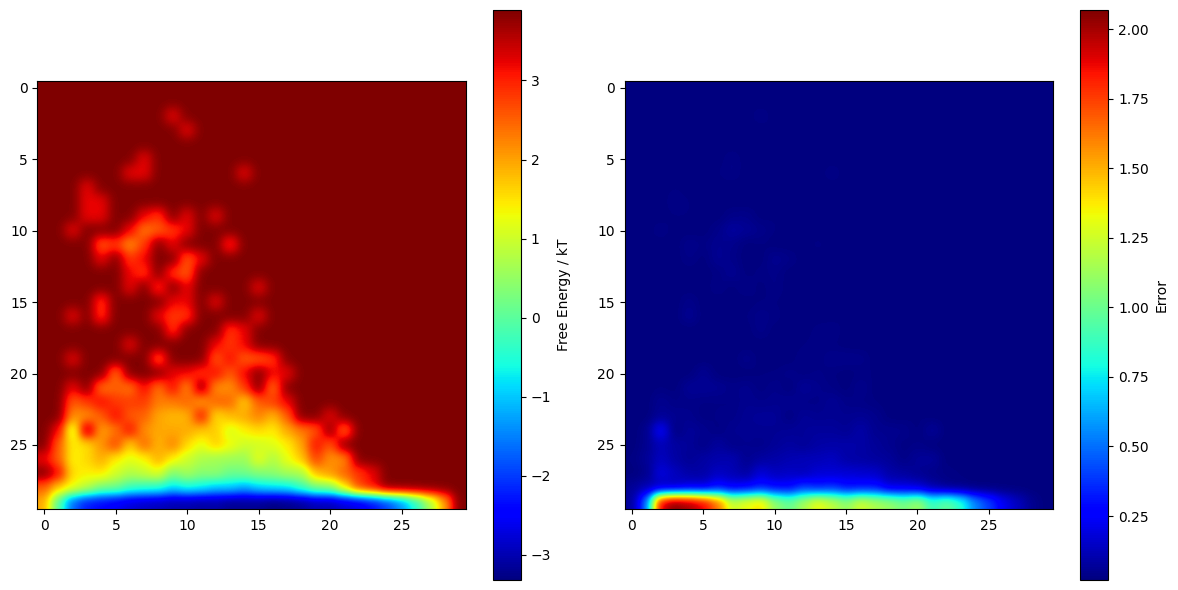

In [174]:
from pyblock.blocking import reblock, find_optimal_block
tflip = lambda x : np.flip(x.T)
n = data.shape[-1]
blocks = reblock(data)
index = int(np.asarray(find_optimal_block(n, blocks)).mean())
size = blocks[index].ndata
print(size)
size = 500
bins = 30
bounds = ((data[0].min(), data[0].max()), (data[1].min(), data[1].max()))
samples = np.stack([np.histogram2d(*i.T, bins=bins, range=bounds)[0]
                     for i in np.array_split(data.T, np.cumsum(np.ones(n // size) * size).astype(int))])

mean, var = samples.mean(0), np.sqrt(samples.var(0) / len(samples))
def adjust_min(x):
    idx = (x == 0)
    x[idx] = x[~idx].min()
    return x

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax=axes.flat
s1 = ax[0].imshow(np.flip(-np.log(adjust_min(mean)).T, 0), cmap="jet", interpolation="gaussian")
plt.colorbar(s1, ax=ax[0],label="Free Energy / kT",)
s2 = ax[1].imshow(np.flip(adjust_min(var).T, 0), cmap="jet", interpolation="gaussian",)
plt.colorbar(s2, ax=ax[1], label="Error")
plt.tight_layout()

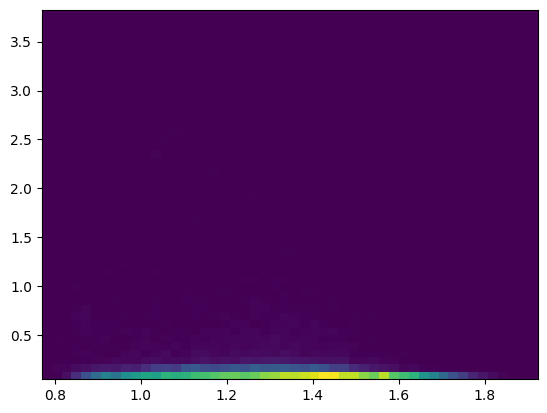

In [135]:
_=plt.hist2d(*data, bins=50)

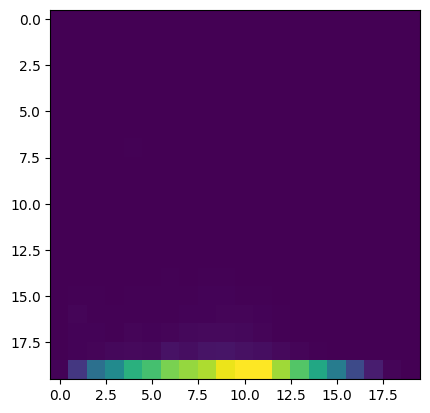

In [131]:
plt.imshow(np.flip((mean / mean.sum()).T, axis=0), )

In [87]:
var_t = [var[i][i] for i in range(var.shape[0])]

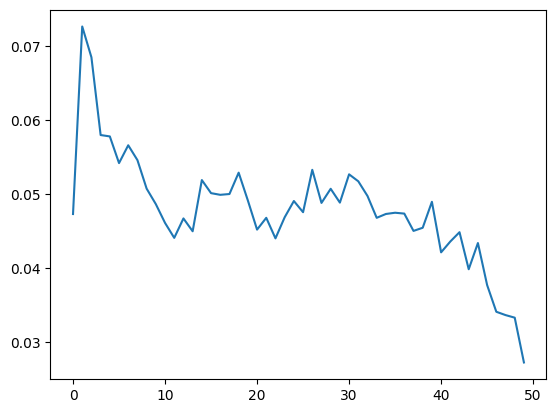

In [91]:
plt.plot(var_t)